In [18]:
#Step 1 — Load the Dataset and Inspect Basic Information
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\varsh\\OneDrive\\Desktop\\teleservices_ml_project\\Telehealth-Services-Provided-to-the-MedicaidCHIP-Population (1).csv")

# Show first 5 rows
df.head()

,State,Year,Month,TelehealthType,ServiceType,ServiceCount,RatePer1000Beneficiaries,DataQuality
0,Alabama,2018,201801,Live audio/video,All,"6,905",5.6,NaN
1,Alabama,2018,201801,Other telehealth,All,-,0,NaN
2,Alabama,2018,201801,Remote patient monitoring,All,-,0,NaN
3,Alabama,2018,201801,Store and forward,All,-,0,NaN
4,Alabama,2018,201802,Live audio/video,All,"4,821",3.9,NaN


In [19]:
df.shape

(12720, 8)

In [20]:
df.describe()

,Year,Month
count,12720.000000,12720.000000
mean,2020.000000,202006.500000
std,1.414269,141.469043
min,2018.000000,201801.000000
25%,2019.000000,201903.750000
50%,2020.000000,202006.500000
75%,2021.000000,202109.250000
max,2022.000000,202212.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12720 entries, 0 to 12719
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   State                     12720 non-null  object
 1   Year                      12720 non-null  int64 
 2   Month                     12720 non-null  int64 
 3   TelehealthType            12720 non-null  object
 4   ServiceType               12720 non-null  object
 5   ServiceCount              12720 non-null  object
 6   RatePer1000Beneficiaries  12720 non-null  object
 7   DataQuality               660 non-null    object
dtypes: int64(2), object(6)
memory usage: 795.1+ KB


In [22]:
#Step 3 — Clean ServiceCount and RatePer1000Beneficiaries
# Clean ServiceCount properly
df["ServiceCount"] = df["ServiceCount"].astype(str).str.replace(",", "", regex=False).str.strip()
df["ServiceCount"] = df["ServiceCount"].replace("-", pd.NA)
df["ServiceCount"] = pd.to_numeric(df["ServiceCount"], errors="coerce")

# Clean RatePer1000Beneficiaries properly
df["RatePer1000Beneficiaries"] = df["RatePer1000Beneficiaries"].astype(str).str.replace(",", "", regex=False).str.strip()
df["RatePer1000Beneficiaries"] = pd.to_numeric(df["RatePer1000Beneficiaries"], errors="coerce")

# Check result
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12720 entries, 0 to 12719
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   State                     12720 non-null  object 
 1   Year                      12720 non-null  int64  
 2   Month                     12720 non-null  int64  
 3   TelehealthType            12720 non-null  object 
 4   ServiceType               12720 non-null  object 
 5   ServiceCount              8842 non-null   float64
 6   RatePer1000Beneficiaries  10676 non-null  float64
 7   DataQuality               660 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 795.1+ KB


,State,Year,Month,TelehealthType,ServiceType,ServiceCount,RatePer1000Beneficiaries,DataQuality
0,Alabama,2018,201801,Live audio/video,All,6905.0,5.6,NaN
1,Alabama,2018,201801,Other telehealth,All,NaN,0.0,NaN
2,Alabama,2018,201801,Remote patient monitoring,All,NaN,0.0,NaN
3,Alabama,2018,201801,Store and forward,All,NaN,0.0,NaN
4,Alabama,2018,201802,Live audio/video,All,4821.0,3.9,NaN


In [23]:
# Drop useless column
df = df.drop(columns=["DataQuality"])

# Remove rows where target variable is missing
df = df.dropna(subset=["ServiceCount"])

# Check shape and first rows
df.shape


(8842, 7)

In [24]:
df.head()

,State,Year,Month,TelehealthType,ServiceType,ServiceCount,RatePer1000Beneficiaries
0,Alabama,2018,201801,Live audio/video,All,6905.0,5.6
4,Alabama,2018,201802,Live audio/video,All,4821.0,3.9
8,Alabama,2018,201803,Live audio/video,All,2269.0,1.8
12,Alabama,2018,201804,Live audio/video,All,2290.0,1.8
16,Alabama,2018,201805,Live audio/video,All,2380.0,1.9


In [25]:
#Step 5 — Create a Proper Date Column
# Convert Month column to string
df["Month"] = df["Month"].astype(str)

# Create Date column
df["Date"] = pd.to_datetime(df["Month"], format="%Y%m")

# Sort by time
df = df.sort_values("Date")

# Check results
df[["Month", "Date"]].head()


,Month,Date
0,201801,2018-01-01
6002,201801,2018-01-01
6003,201801,2018-01-01
6240,201801,2018-01-01
961,201801,2018-01-01


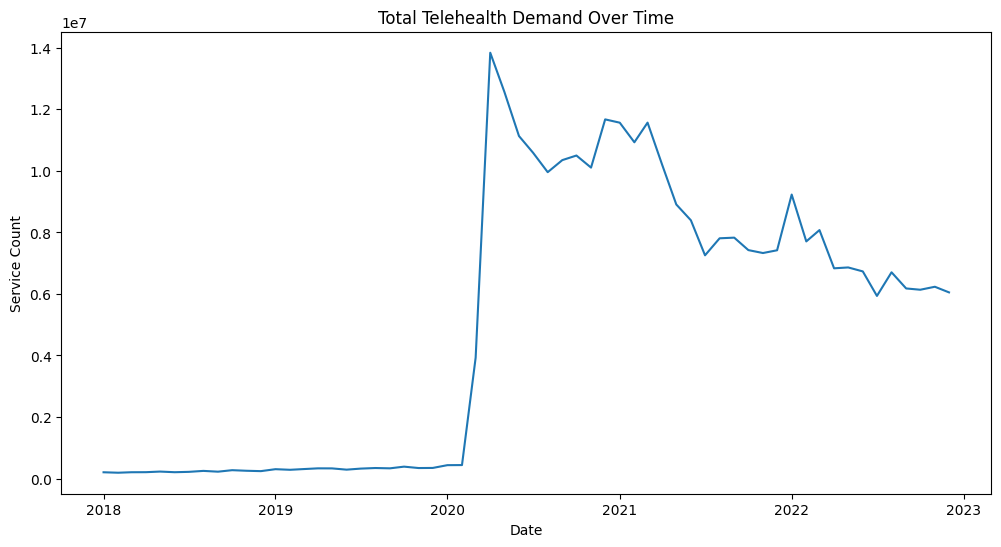

In [26]:
#EDA
#how telehealth demand changes over time.
import matplotlib.pyplot as plt

# Total demand per month
monthly_demand = df.groupby("Date")["ServiceCount"].sum()

# Plot demand trend
plt.figure(figsize=(12,6))
plt.plot(monthly_demand)
plt.title("Total Telehealth Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Service Count")
plt.show()

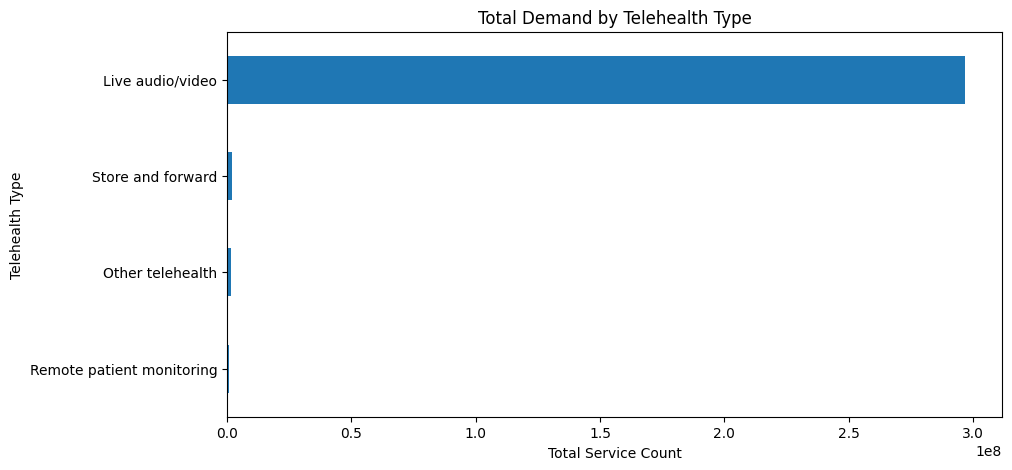

In [27]:
#Analyze Demand by Telehealth Type
telehealth_type_demand = df.groupby("TelehealthType")["ServiceCount"].sum()

plt.figure(figsize=(10,5))
telehealth_type_demand.sort_values().plot(kind="barh")

plt.title("Total Demand by Telehealth Type")
plt.xlabel("Total Service Count")
plt.ylabel("Telehealth Type")
plt.show()

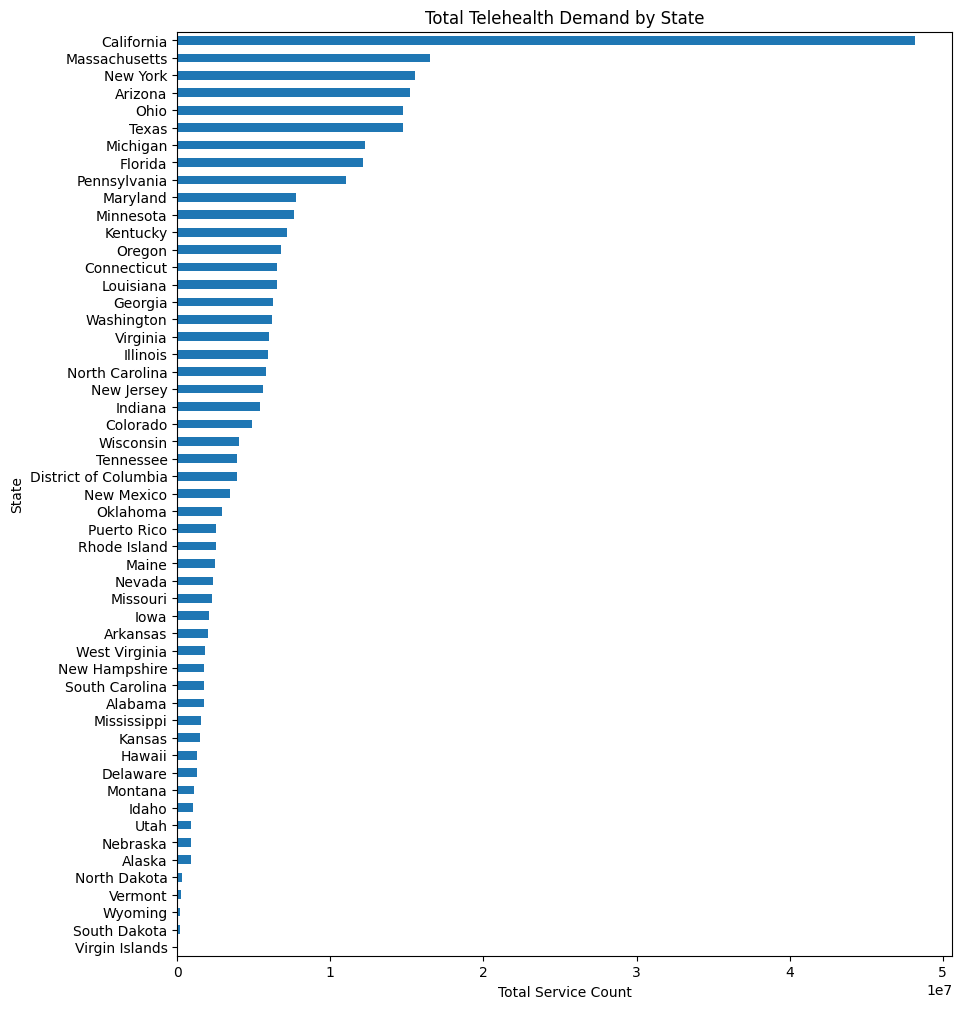

In [28]:
#Step 8 — Analyze Demand by State
#Which states use telehealth the most?
state_demand = df.groupby("State")["ServiceCount"].sum()

plt.figure(figsize=(10,12))
state_demand.sort_values().plot(kind="barh")

plt.title("Total Telehealth Demand by State")
plt.xlabel("Total Service Count")
plt.ylabel("State")
plt.show()

In [29]:
#Step 9 — Feature Engineering
#convert these into numerical features.
df_encoded = pd.get_dummies(df, columns=["State", "TelehealthType", "ServiceType"], drop_first=True)

df_encoded.head()

,Year,Month,ServiceCount,RatePer1000Beneficiaries,Date,State_Alaska,State_Arizona,State_Arkansas,State_California,State_Colorado,...,State_Vermont,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,TelehealthType_Other telehealth,TelehealthType_Remote patient monitoring,TelehealthType_Store and forward
0,2018,201801,6905.0,5.6,2018-01-01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6002,2018,201801,14.0,0.0,2018-01-01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6003,2018,201801,33.0,0.0,2018-01-01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6240,2018,201801,2429.0,8.6,2018-01-01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
961,2018,201801,50.0,0.0,2018-01-01,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [30]:
#Step 10 — Define Target and Features
# Define target
y = df_encoded["ServiceCount"]

# Define features
X = df_encoded.drop(columns=["ServiceCount", "Date"])

X.head()

,Year,Month,RatePer1000Beneficiaries,State_Alaska,State_Arizona,State_Arkansas,State_California,State_Colorado,State_Connecticut,State_Delaware,...,State_Vermont,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming,TelehealthType_Other telehealth,TelehealthType_Remote patient monitoring,TelehealthType_Store and forward
0,2018,201801,5.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6002,2018,201801,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6003,2018,201801,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6240,2018,201801,8.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
961,2018,201801,0.0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [33]:
#Step 11 — Train/Test Split
# Convert Month to numeric
X["Month"] = pd.to_numeric(X["Month"])

# Recreate train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7073, 58)
X_test: (1769, 58)
y_train: (7073,)
y_test: (1769,)


In [34]:
#Step 12 — Train the First Model (Random Forest)
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [35]:
#Step 13 — Make Predictions
rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([6.2810000e+01, 4.3753846e+05, 9.3440000e+01, 2.7180000e+01,
       9.2260000e+01, 1.4626000e+02, 4.2700000e+01, 5.3427000e+02,
       5.1487300e+03, 1.9779650e+05])

In [36]:
#Step 14 — Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1914.4658846806105
RMSE: 7417.924704007705
R² Score: 0.995103662296362


The Random Forest model demonstrates very strong predictive performance with an R² score of 0.995, indicating that the model explains approximately 99.5% of the variation in telehealth service demand. The mean absolute error (MAE) of 1,914 suggests that the model's predictions are highly accurate relative to the scale of the data

In [37]:
#Feature Importance
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

RatePer1000Beneficiaries    0.406583
State_California            0.390051
State_Massachusetts         0.031778
State_New York              0.026375
State_Texas                 0.022107
State_Ohio                  0.017654
State_Florida               0.015989
State_Arizona               0.014680
State_Michigan              0.012322
State_Pennsylvania          0.011544
dtype: float64

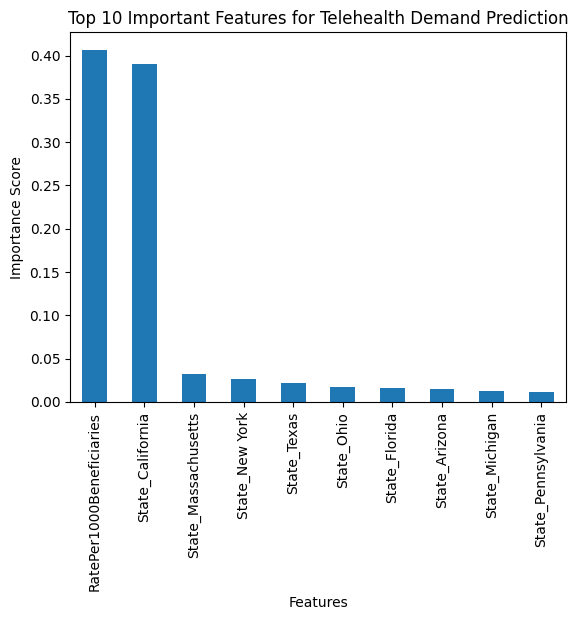

In [38]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features for Telehealth Demand Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [41]:
#XGBoost Model
from xgboost import XGBRegressor

In [42]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [43]:
xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R² Score:", xgb_r2)

XGBoost MAE: 5477.086157130548
XGBoost RMSE: 14191.190409473507
XGBoost R² Score: 0.9820797453491594


In [44]:
#Create Hybrid Model
# Hybrid prediction (average of both models)

hybrid_predictions = (rf_predictions + xgb_predictions) / 2

hybrid_predictions[:10]

array([ 5.19183412e+02,  4.10080949e+05,  9.33699634e+01,  9.72594336e+01,
        9.39162715e+02,  1.55554110e+02, -3.32474646e+02,  6.21714956e+02,
        4.64202955e+03,  1.89883078e+05])

In [45]:
hybrid_mae = mean_absolute_error(y_test, hybrid_predictions)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_predictions))
hybrid_r2 = r2_score(y_test, hybrid_predictions)

print("Hybrid MAE:", hybrid_mae)
print("Hybrid RMSE:", hybrid_rmse)
print("Hybrid R² Score:", hybrid_r2)

Hybrid MAE: 3363.7933341653875
Hybrid RMSE: 9608.924989599544
Hybrid R² Score: 0.9917840813833779


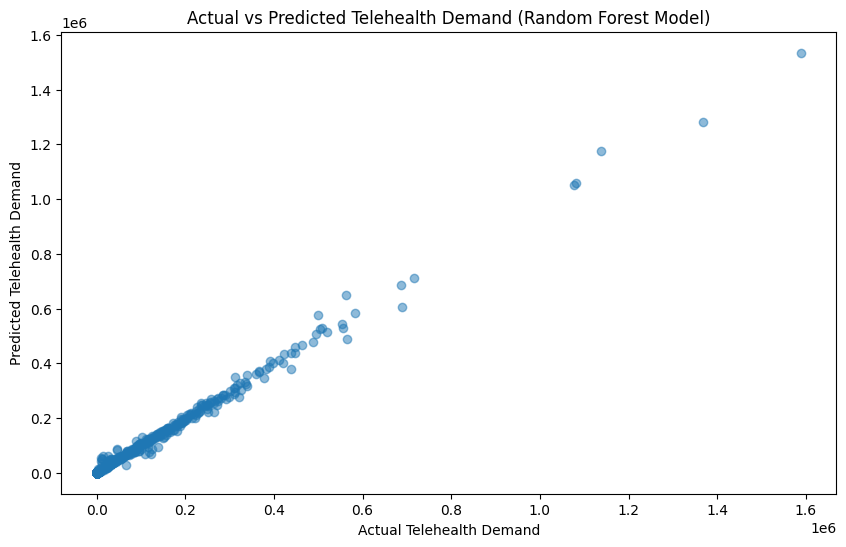

In [47]:
#Actual vs Predicted graphs.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.xlabel("Actual Telehealth Demand")
plt.ylabel("Predicted Telehealth Demand")

plt.title("Actual vs Predicted Telehealth Demand (Random Forest Model)")

plt.show()

In [48]:
import joblib

joblib.dump(rf_model, "telehealth_demand_model.pkl")

['telehealth_demand_model.pkl']

In [49]:
import os
print(os.path.exists("telehealth_demand_model.pkl"))

True


In [50]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [51]:
print(feature_columns[:10])
print(len(feature_columns))

['Year', 'Month', 'RatePer1000Beneficiaries', 'State_Alaska', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Connecticut', 'State_Delaware']
58
